In [1]:
from stable_baselines3 import PPO
from kaggle_environments import make
import numpy as np
import random
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation
/usr/local/lib/python3.10/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.10/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packa

In [2]:
path = "data"

all_files = glob.glob(os.path.join(path, "*.csv"))

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df.head()

,model,version,vs random win,vs random invalid,vs look win,vs look invalid,vs negamax win,vs negamax invalid,saved on
0,model_control_120big_v8,100000,0.93,0,0.07,0,0.06,0.06,2025-02-11 16:00:55.522134
1,model_control_120big_v8,200000,0.92,0,0.05,0,0.09,0.09,2025-02-11 16:11:55.877479
2,model_control_120big_v8,300000,0.96,0,0.07,0,0.04,0.04,2025-02-11 16:23:18.314707
3,model_control_120big_v8,400000,0.71,0,0.01,0,0.01,0.01,2025-02-11 16:43:03.640896
4,model_control_120big_v8,500000,0.75,0,0.06,0,0.00,0.00,2025-02-11 16:58:02.108660


In [3]:
# Models 

df.model.unique()

array(['model_control_120big_v8'], dtype=object)

# All models

Vs random

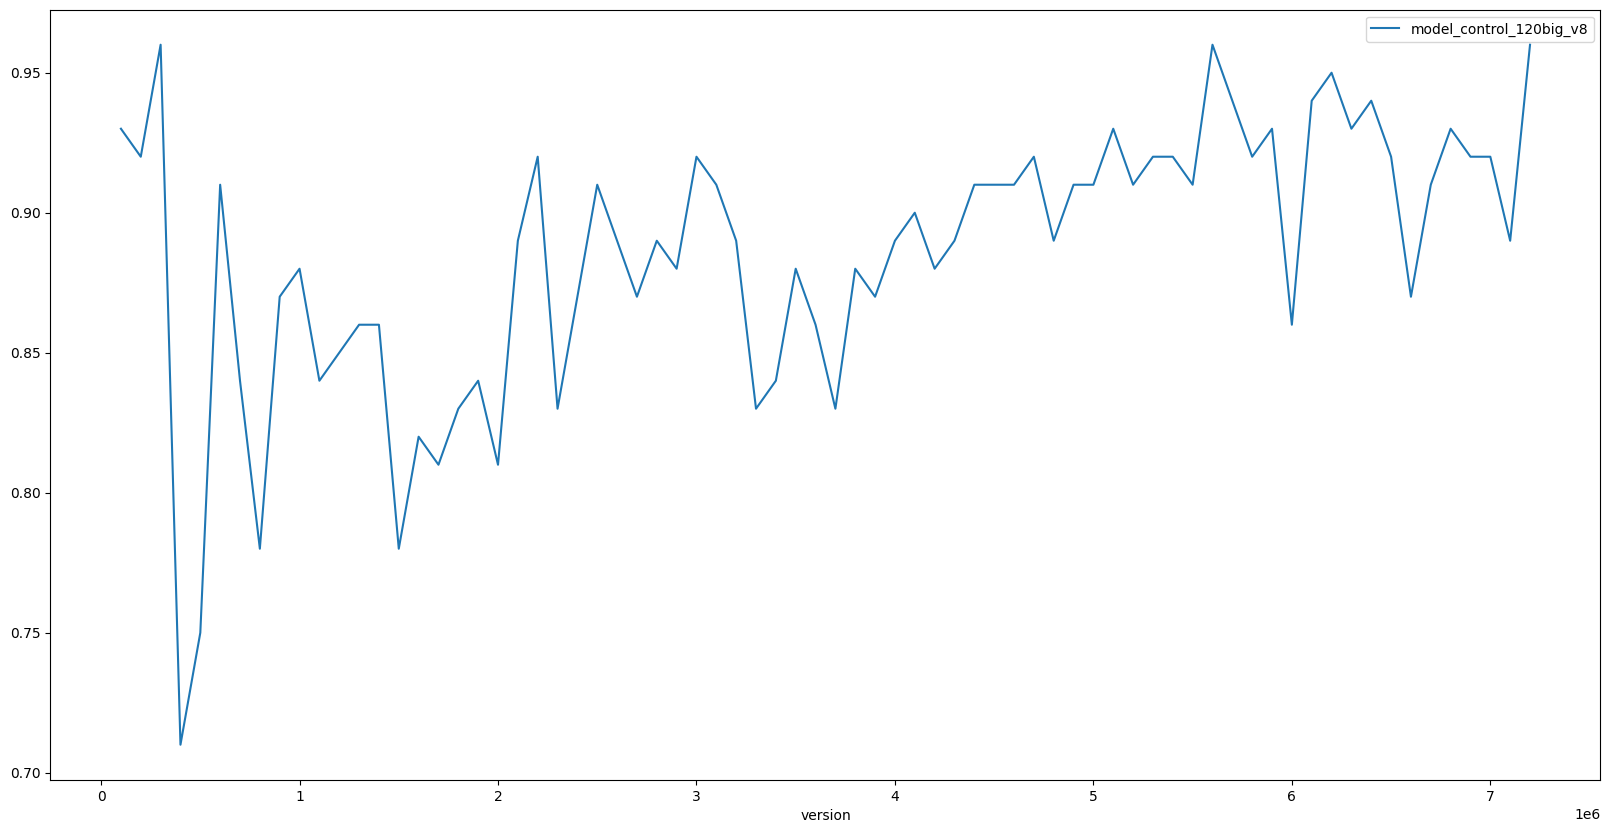

In [ ]:
filter_out = []

df_vs_random = df[['model', 'version', 'vs random win', 'vs look win']]
df_vs_random.set_index('version', inplace=True)

df_vs_random[~df_vs_random['model'].isin(filter_out)].groupby("model")['vs random win'].plot(x='version', subplots=False, legend=True, figsize=(20, 10))
plt.show()

model
model_control_120big_v8    0.884861
Name: vs random win, dtype: float64


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: title={'center': 'AVG vs random winds'}, ylabel='model'>

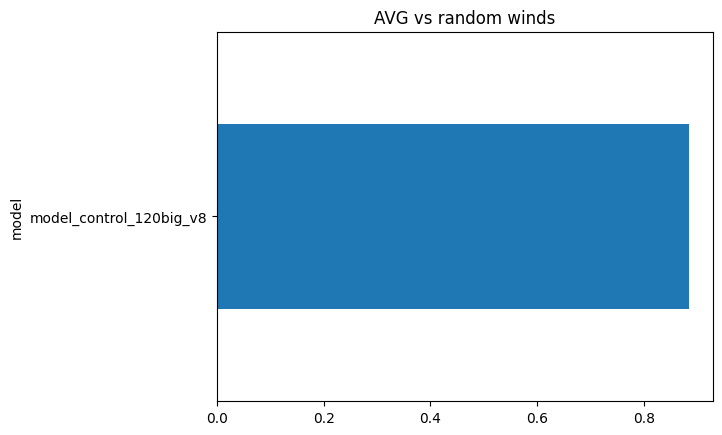

In [5]:
print(df_vs_random.groupby("model")['vs random win'].mean())
df_vs_random.groupby("model")['vs random win'].mean().plot(kind='barh', y='vs random win', title='AVG vs random winds')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


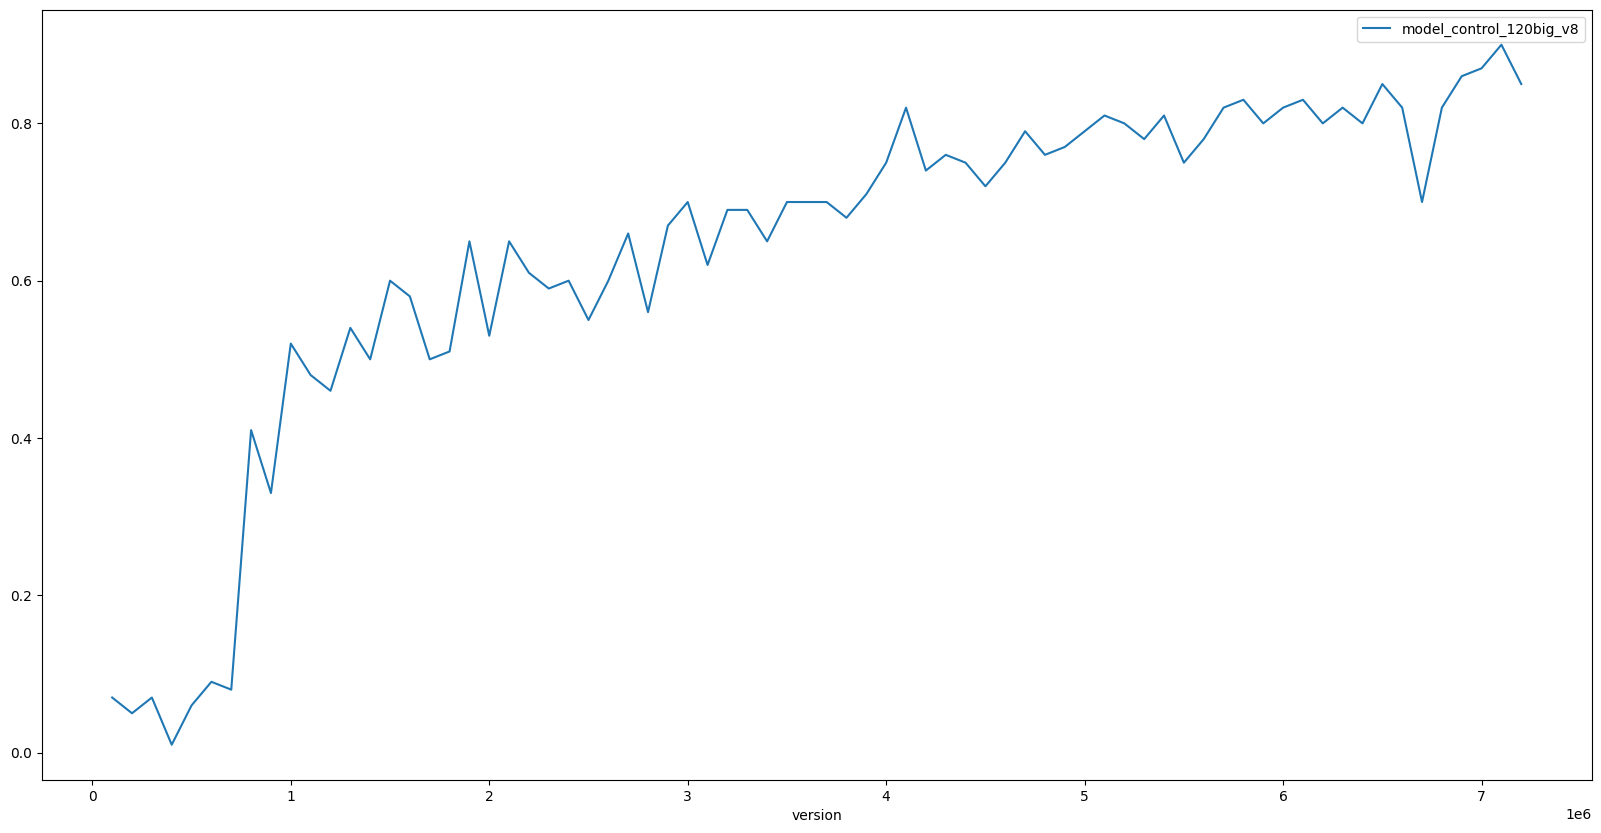

In [6]:
df_vs_random.groupby("model")['vs look win'].plot(x='version', subplots=False, legend=True, figsize=(20, 10))
plt.show()

model
model_control_120big_v8    0.634583
Name: vs look win, dtype: float64


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: title={'center': 'AVG vs look win'}, ylabel='model'>

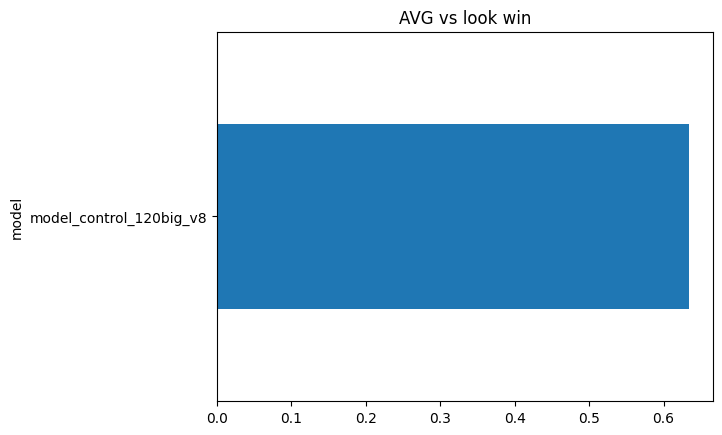

In [7]:
print(df_vs_random.groupby("model")['vs look win'].mean())
df_vs_random.groupby("model")['vs look win'].mean().plot(kind='barh', y='vs look win', title='AVG vs look win')

model
model_control_120big_v8    0.9
Name: vs look win, dtype: float64


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: title={'center': 'MAX vs Look Max'}, ylabel='model'>

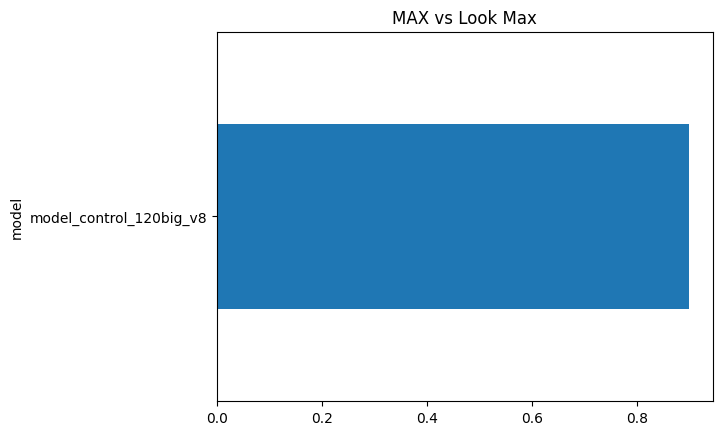

In [8]:
print(df_vs_random.groupby("model")['vs look win'].max())
df_vs_random.groupby("model")['vs look win'].max().plot(kind='barh', y='vs look win', title='MAX vs Look Max')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


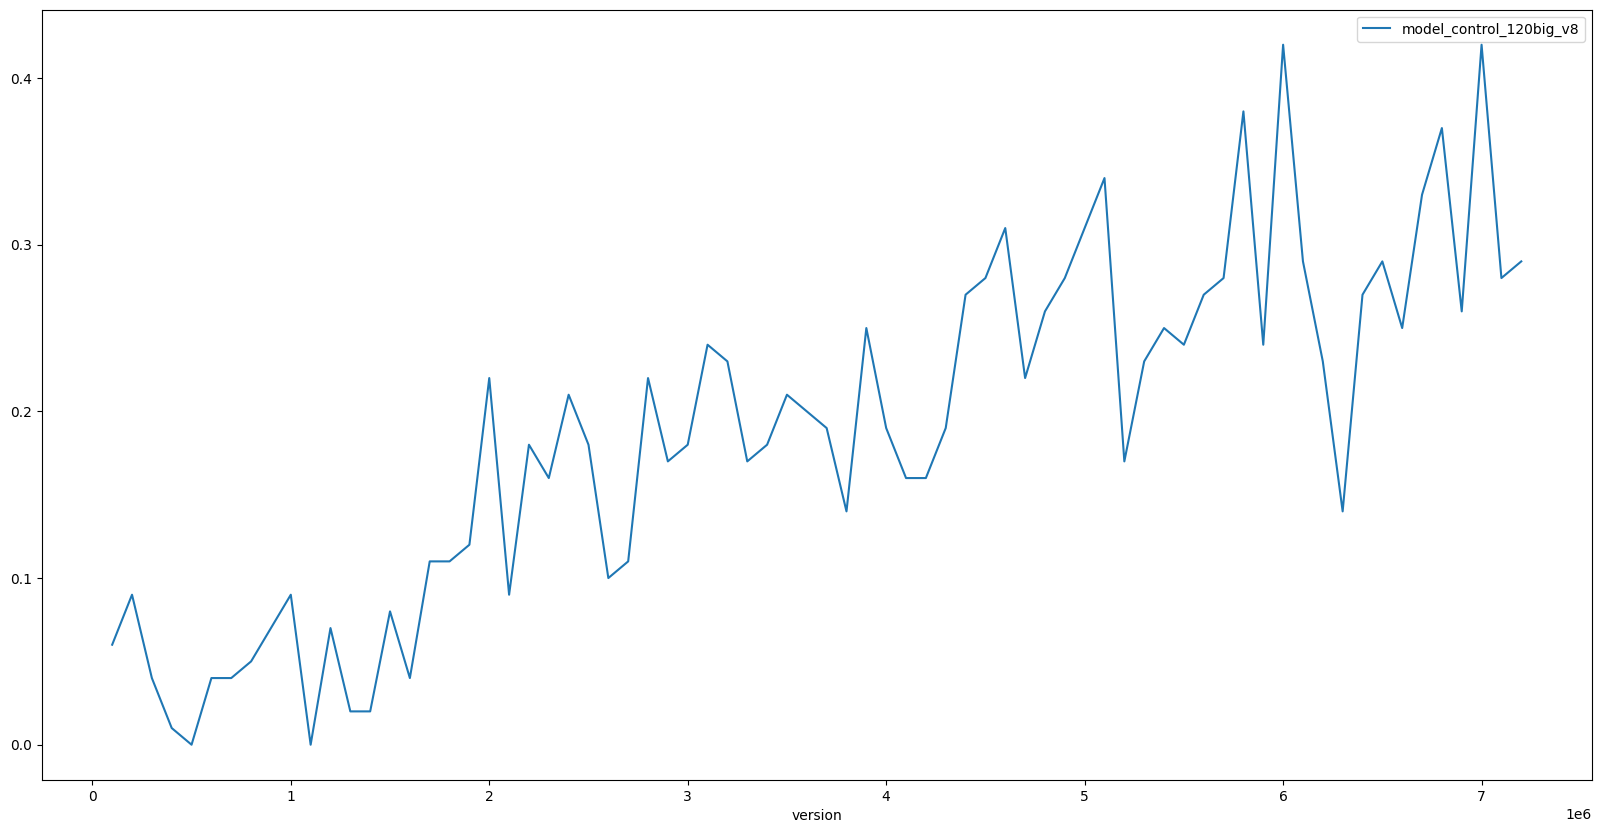

In [9]:
filter_out = []

df_vs_negamax = df[['model', 'version', 'vs negamax win']]
df_vs_negamax.set_index('version', inplace=True)


df_vs_negamax[~df_vs_random['model'].isin(filter_out)].groupby("model")['vs negamax win'].plot(x='version', subplots=False, legend=True, figsize=(20, 10))
plt.show()

In [10]:
def plot_model(df, model_name):
    df_single_model = df[['model', 'version', 'vs random win', 'vs look win']]
    df_single_model[df['model'] == model_name].plot(x='version', subplots=False, legend=True, figsize=(20, 10))
    plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [21]:
from connectx.utils import get_win_percentages, get_win_percentages_first
from connectx.environment import ConnectFourGymV2,ConnectFourGymV8
from connectx.lookahead import multistep_agent_factory


In [26]:
df.sort_values(['vs negamax win', 'vs look win', 'vs random win'], ascending=False).head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,model,version,vs random win,vs random invalid,vs look win,vs look invalid,vs negamax win,vs negamax invalid,saved on
69,model_control_120big_v8,7000000,0.92,0,0.87,0,0.42,0.00,2025-02-12 10:02:53.207477
59,model_control_120big_v8,6000000,0.86,0,0.82,0,0.42,0.42,2025-02-12 05:10:13.385505
57,model_control_120big_v8,5800000,0.92,0,0.83,0,0.38,0.38,2025-02-12 04:44:09.950881
67,model_control_120big_v8,6800000,0.93,0,0.82,0,0.37,0.37,2025-02-12 06:54:58.183209
50,model_control_120big_v8,5100000,0.93,0,0.81,0,0.34,0.34,2025-02-12 03:12:27.556331


In [23]:
from connectx.models.model_control_120big_v8 import get_model

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [25]:
env = ConnectFourGymV8()
look_agent = multistep_agent_factory()
learner = get_model(env)
learner.load_model_version(env, "7000000")
agent = learner.get_agent()
results = get_win_percentages_first(agent, "random")
print("STARTING First")
print(results)
results = get_win_percentages_first("random", agent)
print("STARTING Second")
print(results)
print("-------------------")
results = get_win_percentages_first(agent, look_agent)
print("STARTING First vs Look agent")
print(results)
results = get_win_percentages_first(look_agent, agent)
print("STARTING Second vs Look agent")
print(results)
print("-------------------")
results = get_win_percentages_first(agent, "negamax")
print("STARTING First vs Negamax")
print(results)
results = get_win_percentages_first("negamax", agent)
print("STARTING Second vs Negamax")
print(results)

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/policies.py:460: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See htt

Getting agent
STARTING First
Results(agent1_wins=0.95, agent2_wins=0.05, agent1_inv=0, agent2_inv=0)
STARTING Second
Results(agent1_wins=0.13, agent2_wins=0.86, agent1_inv=0, agent2_inv=0)
STARTING First vs Look agent
Results(agent1_wins=0.93, agent2_wins=0.06, agent1_inv=0, agent2_inv=0)
STARTING Second vs Look agent
Results(agent1_wins=0.21, agent2_wins=0.78, agent1_inv=0, agent2_inv=0)
STARTING First vs Negamax
Results(agent1_wins=0.61, agent2_wins=0.39, agent1_inv=0, agent2_inv=0)
STARTING Second vs Negamax
Results(agent1_wins=0.67, agent2_wins=0.32, agent1_inv=0, agent2_inv=0)


In [188]:
env = ConnectFourGymV2()
look_agent = multistep_agent_factory()
learner = get_model(env)
learner.load_model_version(env, "700000")
agent = learner.get_agent()
results = get_win_percentages_first(agent, "random")
print("STARTING First vs Random")
print(results)
results = get_win_percentages_first("random", agent)
print("STARTING Second vs Random")
print(results)

results = get_win_percentages_first(agent, look_agent)
print("STARTING First vs Look agent")
print(results)
results = get_win_percentages_first(look_agent, agent)
print("STARTING Second vs Look agent")
print(results)

Getting agent
STARTING First vs Random
Results(agent1_wins=0.95, agent2_wins=0.05, agent1_inv=0, agent2_inv=0)
STARTING Second vs Random
Results(agent1_wins=0.31, agent2_wins=0.69, agent1_inv=0, agent2_inv=0)
STARTING First vs Look agent
Results(agent1_wins=0.37, agent2_wins=0.61, agent1_inv=0, agent2_inv=0)
STARTING Second vs Look agent
Results(agent1_wins=0.99, agent2_wins=0.01, agent1_inv=0, agent2_inv=0)
